In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
quick_test=False

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from scipy.interpolate import interp1d
import pandas as pd
import sncosmo
from scipy import stats
from scipy.special import expit
from nested_pandas import read_parquet
from joblib import Parallel, delayed
import cloudpickle as pickle
from regions import RectangleSkyRegion
from astropy.coordinates import SkyCoord
import astropy.units as u
from scipy.optimize import curve_fit

from lightcurvelynx.obstable.ztf_obstable import ZTFObsTable
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.pzflow_node import PZFlowNode
from lightcurvelynx.astro_utils.snia_utils import (
    DistModFromRedshift,
    HostmassX1Func,
    X0FromDistMod,
    num_snia_per_redshift_bin,
    SNCoordGivenPhysicalSep,
)
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.models.sncomso_models import SncosmoWrapperModel
from lightcurvelynx.models.snia_host import SNIaHost
from lightcurvelynx.utils.plotting import plot_lightcurves
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableUniformRADECSampler
from lightcurvelynx.astro_utils.dustmap import DustmapWrapper,SFDMap
from lightcurvelynx.effects.extinction import ExtinctionEffect
from lightcurvelynx.astro_utils.mag_flux import mag2flux,flux2mag
from lightcurvelynx.astro_utils.detector_footprint import DetectorFootprint

from lightcurvelynx import _LIGHTCURVELYNX_BASE_DATA_DIR

from lightcurvelynx.validation.lcfit import fit_single_lc

In [4]:
globalhostdata = pd.read_csv('ztfsniadr2/tables/globalhost_data.csv')
localhostdata = pd.read_csv('ztfsniadr2/tables/localhost_data.csv')
sndata = pd.read_csv('ztfsniadr2/tables/snia_data.csv')
data = pd.merge(sndata,globalhostdata,on='ztfname')

In [5]:
lcdata = read_parquet('data/ztfsniadr2.parquet')

In [6]:
%%time

obs_log = pd.read_parquet('data/ztf_observing_log_combined_w_metadata.parquet')
colmap = {"ra":"ra",
          "dec":"dec",
          "time":"mjd",
          "zp":"zp_nJy",
          "filter":"filter",
          "sky":"scibckgnd",
         }

#ztf ccd size 6144 × 6160 pixel * 16
pixel_scale = 1.01 #arcsec/pixel
center = SkyCoord(ra=0.0, dec=0.0, unit="deg", frame="icrs")
rect_region = RectangleSkyRegion(center=center, width=6144.* pixel_scale * u.arcsec, 
                                 height=6160.* pixel_scale * u.arcsec, angle=0.0 * u.deg)
ztf_fp = DetectorFootprint(rect_region, pixel_scale=pixel_scale)

ztf_obstable = ZTFObsTable(obs_log,colmap=colmap)#,detector_footprint=ztf_fp)
# ztf_obstable.radius = 3.868

t_min, t_max = ztf_obstable.time_bounds()
print(f"Loaded OpSim with {len(ztf_obstable)} rows and times [{t_min}, {t_max}]")

passband_group = PassbandGroup.from_preset(preset="ZTF", filters=["g", "r", "i"])
print(f"Loaded Passbands: {passband_group}")

2025-10-01 09:40:19,932 - INFO - Loading passbands from preset ZTF


Loaded OpSim with 520115 rows and times [58288.171875, 59273.5546875]
Loaded Passbands: PassbandGroup containing 3 passbands: ZTF_g, ZTF_r, ZTF_i
CPU times: user 483 ms, sys: 73.6 ms, total: 557 ms
Wall time: 503 ms


In [7]:
radec_node = ObsTableUniformRADECSampler(ztf_obstable, radius=ztf_obstable.radius, node_label="radec")

zmin = 0.001
zmax = 0.2
H0 = 70.0
Omega_m = 0.3
nsn, z = num_snia_per_redshift_bin(zmin, zmax, 100, H0=H0, Omega_m=Omega_m)
zpdf = interp1d(z, nsn, bounds_error=False, fill_value=0)

host = SNIaHost(
    ra = radec_node.ra,
    dec = radec_node.dec,
    hostmass=10.,
    redshift=SamplePDF(zpdf),
    node_label="host",
)

In [8]:
distmod_func = DistModFromRedshift(host.redshift, H0=H0, Omega_m=Omega_m)
x1_func = NumpyRandomFunc("uniform",low=-5.,high=5.)
c_func = NumpyRandomFunc("uniform",low=-0.5,high=1.)
m_abs_func = NumpyRandomFunc("normal", loc=-19.05, scale=0.1)

# we model host-sn separation as an exponential distribution based on Fig 3 of Gupta et al 2016, mean separation = 5kpc
physical_host_sn_sep = NumpyRandomFunc("exponential", scale = 5.)
sncoor_node = SNCoordGivenPhysicalSep(host.ra, host.dec, physical_host_sn_sep, host.redshift, H0=H0, Omega_m=Omega_m,node_label='sncoor_node')

x0_func = X0FromDistMod(
    distmod=distmod_func,
    x1=x1_func,
    c=c_func,
    alpha=0.14,
    beta=3.1,
    m_abs=m_abs_func,
    node_label="x0_func",
)

sncosmo_modelname = "salt3"
source = SncosmoWrapperModel(
    sncosmo_modelname,
    t0=NumpyRandomFunc("uniform", low=t_min, high=t_max),
    x0=x0_func,
    x1=x1_func,
    c=c_func,
    ra=sncoor_node.ra,
    dec=sncoor_node.dec,
    redshift=host.redshift,
    node_label="source",
)
    
mwextinction = SFDMap(
    ra=source.ra,
    dec=source.dec,
    node_label="mwext",
)

# Create an extinction effect using the EBVs from that dust map.
ext_effect = ExtinctionEffect(extinction_model="F99", frame='observer', ebv=mwextinction, Rv=3.1)
source.add_effect(ext_effect)


2025-10-01 09:40:20,546 - INFO - SFD dust map data files not found.
Attempting to download from: ('https://github.com/kbarbary/sfddata/archive/master.tar.gz',)
to the directory /Users/mi/Work/lightcurvelynx/lightcurvelynx/data/dustmaps/sfdmap2


In [9]:
%%time
if quick_test:
    nsntotal = 3000
else:
    survey_length = (t_max - t_min)/365.
    nsntotal, _ = num_snia_per_redshift_bin(zmin, zmax, 1, H0=H0, Omega_m=Omega_m, solid_angle=9.136*survey_length*2)
    print(f"Survey length = {survey_length} years")
print(f"Simulating {int(nsntotal)} SN ...")
lightcurves = simulate_lightcurves(source, int(nsntotal), ztf_obstable, passband_group)
lightcurves

Survey length = 2.6996789383561643 years
Simulating 257537 SN ...


<timed exec>:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
<timed exec>:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


CPU times: user 17min 59s, sys: 3min 18s, total: 21min 18s
Wall time: 21min 41s


id          ra        dec  nobs            t0         z  \
0            0  250.853588  71.781876  1414  59136.095869  0.162672   
1            1  307.602736 -23.472226   137  58584.288114  0.124146   
...        ...         ...        ...   ...           ...       ...   
257535  257535  287.054797  -8.624232   744  58833.406404  0.187645   
257536  257536   14.961534  21.767849   188  58904.356359  0.130158   

                                                   params  \
0       {'radec.ra': 250.85295505585862, 'radec.dec': ...   
1       {'radec.ra': 307.602545725589, 'radec.dec': -2...   
...                                                   ...   
257535  {'radec.ra': 287.05504211713804, 'radec.dec': ...   
257536  {'radec.ra': 14.9607765934382, 'radec.dec': 21...   

                                               lightcurve  
0       [{mjd: 58288.269531, filter: 'r', flux: 2372.8...  
1       [{mjd: 58289.460938, filter: 'r', flux: 167.60...  
...                                                   ...  
257535  [{mjd: 58288.398438, filter: 'g', flux: 1770.0...  
257536  [{mjd: 58332.496094, filter: 'g', flux: -7475....  

[257537 rows x 8 columns]

In [10]:
lightcurves['params'][0].keys()

dict_keys(['radec.ra', 'radec.dec', 'host.ra', 'host.dec', 'host.redshift', 'host.t0', 'host.distance', 'host.hostmass', 'SamplePDF:_rvs_4.function_node_result', 'sncoor_node.host_ra', 'sncoor_node.host_dec', 'sncoor_node.physical_sep_kpc', 'sncoor_node.redshift', 'sncoor_node.ra', 'sncoor_node.dec', 'NumpyRandomFunc:exponential_5.scale', 'NumpyRandomFunc:exponential_5.function_node_result', 'source.ra', 'source.dec', 'source.redshift', 'source.t0', 'source.distance', 'source.x0', 'source.x1', 'source.c', 'source.Rv', 'source.ebv', 'NumpyRandomFunc:uniform_6.low', 'NumpyRandomFunc:uniform_6.high', 'NumpyRandomFunc:uniform_6.function_node_result', 'DistModFromRedshift:_distmod_from_redshift_8.redshift', 'DistModFromRedshift:_distmod_from_redshift_8.function_node_result', 'x0_func.distmod', 'x0_func.x1', 'x0_func.c', 'x0_func.alpha', 'x0_func.beta', 'x0_func.m_abs', 'x0_func.function_node_result', 'NumpyRandomFunc:uniform_9.low', 'NumpyRandomFunc:uniform_9.high', 'NumpyRandomFunc:uniform

In [11]:
lightcurves.lightcurve.isna().sum()

np.int64(17)

In [12]:
# calculate detection flag
lightcurves = lightcurves.dropna(subset=['lightcurve'])
print("Before applying detection: nsn=", len(lightcurves))
lightcurves['lightcurve.snr'] = lightcurves['lightcurve.flux']/lightcurves['lightcurve.fluxerr']
detection_snr_thres = 5.
lightcurves['lightcurve.detection_flag'] = lightcurves['lightcurve.snr'] > detection_snr_thres

lightcurves_after_detection = lightcurves.query("lightcurve.detection_flag == True").dropna()
print("After applying detection: nsn=", len(lightcurves_after_detection))

Before applying detection: nsn= 257520


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:407: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().__setitem__(nested, new_nested_series)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:407: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().__setitem__(nested, new_nested_series)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/c

After applying detection: nsn= 98859


In [13]:
# apply spec selection function

def spec_selection_func(flux,m0=18.8,s=4.5):
    m = flux2mag(np.max(flux))
    p = np.power(1. + np.exp((m - m0)*s), -1)
    p0 = np.random.uniform(0,1)
    if p0 < p:
        return {"pass_spec_selection":True}
    else:
        return {"pass_spec_selection":False}

pass_selection = lightcurves_after_detection.reduce(spec_selection_func,"lightcurve.flux")
idx = pass_selection.query("pass_spec_selection == True").index
lightcurves_after_spec_selection = lightcurves_after_detection.loc[idx]
print("After spectroscopic selection: nsn=", len(lightcurves_after_spec_selection))

lightcurves["pass_spec_selection"] = False
lightcurves.loc[idx,"pass_spec_selection"] = True

After spectroscopic selection: nsn= 13549


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:420: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().__setitem__(key, value)


In [14]:
def quality_cuts(flux,mjd,filter,n_phases=7, n_before_peak=2, n_after_peak=2, n_bands=2):
    peak_idx = np.argmax(flux)
    pass_cut = len(np.unique(np.floor(mjd))) >= n_phases
    pass_cut &= (peak_idx >= n_before_peak - 1) & (len(flux) - peak_idx >= n_after_peak - 1)
    pass_cut &= len(np.unique(filter)) >= n_bands
    return {"pass_quality_cuts": pass_cut}

In [15]:
pass_quality_cut = lightcurves_after_spec_selection.reduce(quality_cuts,"lightcurve.flux",
                                                           "lightcurve.mjd","lightcurve.filter")
idx = pass_quality_cut.query("pass_quality_cuts == True").index
lightcurves_after_quality_cut = lightcurves_after_spec_selection.loc[idx]
print("After quality cuts: nsn=", len(lightcurves_after_quality_cut))

lightcurves["pass_quality_cuts"] = False
lightcurves.loc[idx,"pass_quality_cuts"] = True

After quality cuts: nsn= 10448


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:420: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().__setitem__(key, value)


In [16]:
sim_all_x1 = [lightcurves.loc[i]['params']['source.x1'] for i in lightcurves.index]
sim_all_c = [lightcurves.loc[i]['params']['source.c'] for i in lightcurves.index]

In [17]:
sim_x1 = [lightcurves.loc[i]['params']['source.x1'] for i in lightcurves.loc[lightcurves['pass_quality_cuts']].index]
sim_c = [lightcurves.loc[i]['params']['source.c'] for i in lightcurves.loc[lightcurves['pass_quality_cuts']].index]

Text(0.5, 1.0, 'x1')

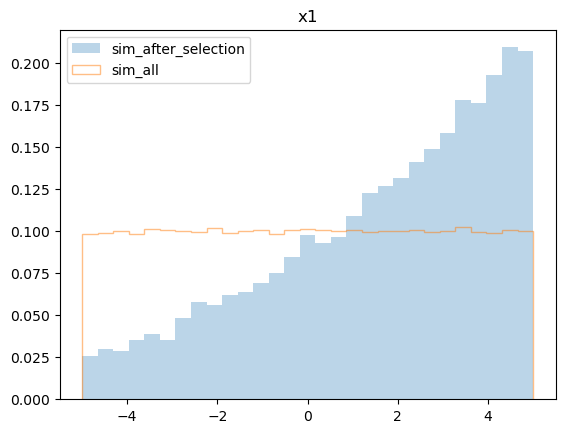

In [18]:
bins=np.linspace(-5,5,30)
plt.hist(sim_x1,bins=bins,alpha=0.3,density=True,label='sim_after_selection')
plt.hist(sim_all_x1,bins=bins,alpha=0.5,density=True,label='sim_all',histtype='step')
plt.legend()
plt.title('x1')

Text(0.5, 1.0, 'c')

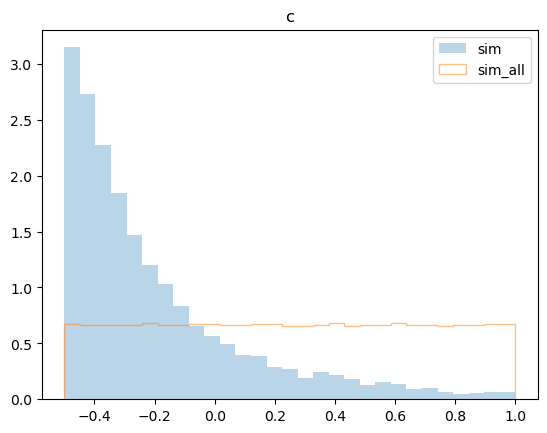

In [19]:
bins=np.linspace(-0.5,1,30)
plt.hist(sim_c,bins=bins,alpha=0.3,density=True,label='sim')
plt.hist(sim_all_c,bins=bins,alpha=0.5,density=True,label='sim_all',histtype='step')
plt.legend()
plt.title('c')

In [20]:
def expo(x, a, b, c):
    x = np.asarray(x)
    y = a * np.exp(b * x) + c
    return y

[ 0.05437554  0.13646395 -0.01816677]


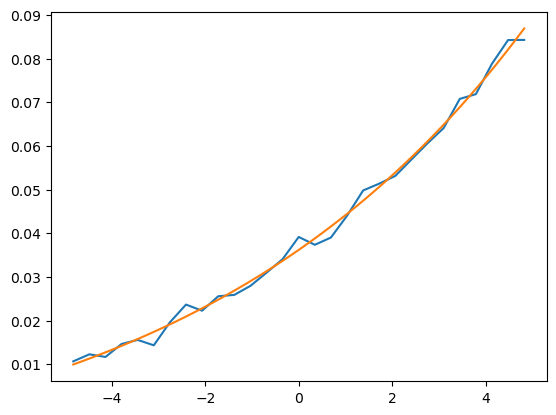

In [21]:
bins = np.linspace(-5,5,30)
x1before,bin_edges,_ = stats.binned_statistic(sim_all_x1,np.ones(len(lightcurves)), statistic='sum', bins=bins)
x1after,bin_edges,_ =  stats.binned_statistic(sim_x1, np.ones(len(lightcurves_after_quality_cut)), statistic='sum', bins=bins)
x_x1 = (bin_edges[:-1] + bin_edges[1:])/2.
f_x1 = x1after/x1before
plt.plot(x_x1,f_x1)
outarr = np.array([x_x1,f_x1])

#fit for an exponential curve using curve_fit
popt, pcov = curve_fit(expo, x_x1, f_x1, p0=[1., 1. ,0.], bounds = ([0.0, 0.0, -np.inf], [np.inf, np.inf, np.inf]))
print(popt)
x = np.linspace(x_x1.min(),x_x1.max(),50)
plt.plot(x, expo(x, *popt))
np.savetxt('data/ztf_selection_func_x1.txt',popt)

[ 3.15642471e-02 -3.82310598e+00  3.56863737e-03]


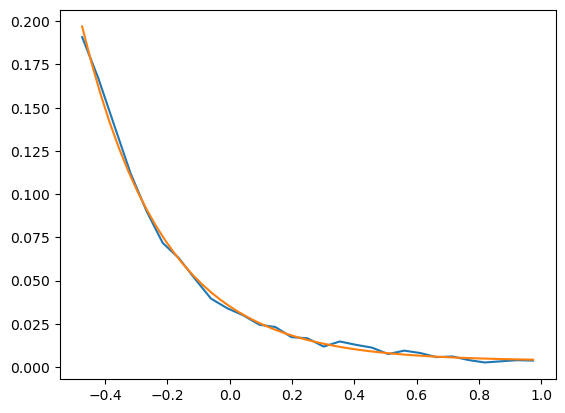

In [22]:
bins = np.linspace(-0.5,1,30)
cbefore,bin_edges,_ = stats.binned_statistic(sim_all_c,np.ones(len(lightcurves)), statistic='sum', bins=bins)
cafter,bin_edges,_ =  stats.binned_statistic(sim_c, np.ones(len(lightcurves_after_quality_cut)), statistic='sum', bins=bins)
x_c = (bin_edges[:-1] + bin_edges[1:])/2.
f_c = cafter/cbefore
plt.plot(x_c,f_c)
outarr = np.array([x_c,f_c])

#fit for an exponential curve using curve_fit
popt, pcov = curve_fit(expo, x_c, f_c, p0=[1., -1. ,0.], bounds = ([0.0, -np.inf, -np.inf], [np.inf, 0.0, np.inf]))
print(popt)
x = np.linspace(x_c.min(),x_c.max(),50)
plt.plot(x, expo(x, *popt))
np.savetxt('data/ztf_selection_func_c.txt',popt)